# Preprocessing and EDA

Runs the full preprocessing pipeline on the complete 7.7M row dataset and displays:
1. Class distribution (full dataset)
2. H3 resolution comparison
3. Weather condition distribution (raw values)
4. Mutual information bar chart (top 20 features)
5. Correlation heatmap of final features
6. Feature count summary
7. Sample rows of the final preprocessed DataFrame

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from data.load_data import load_dataset_sample, train_val_test_split
from preprocessing.pipeline import PreprocessingPipeline, evaluate_h3_resolutions
import config

print("Imports OK")


Imports OK


## Load Dataset

In [2]:
df_raw = load_dataset_sample()
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

Loading dataset from HuggingFace: yuvidhepe/us-accidents-updated
Full dataset shape: (7728394, 46)
Shape after dropping missing Severity: (7728394, 46)
Class distribution:
Severity
2    0.797
3    0.168
4    0.026
1    0.009
Name: proportion, dtype: float64
Shape: (7728394, 46)
Columns: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## 2 Class Distribution

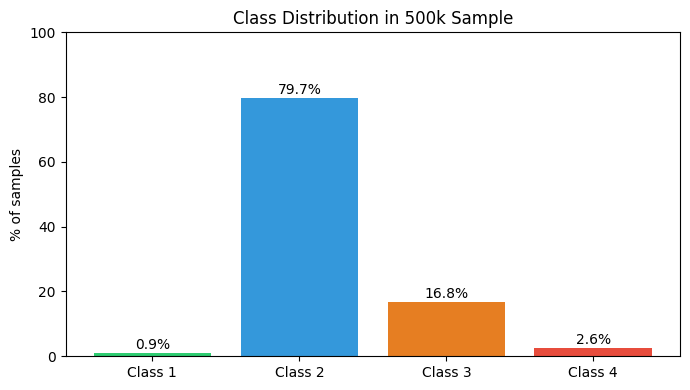

Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64


In [3]:
counts = df_raw['Severity'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'Class {i}' for i in counts.index],
              counts.values / counts.sum() * 100,
              color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
for bar, pct in zip(bars, counts.values / counts.sum() * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('% of samples')
ax.set_title('Class Distribution - Full Dataset (7.7M rows)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(config.PLOTS_DIR, 'class_distribution.png'), dpi=120)
plt.show()
print(counts)

## 3 Train / Val / Test Split

In [4]:
df_train, df_val, df_test = train_val_test_split(df_raw)
print(f'Train class dist:\n{df_train["Severity"].value_counts(normalize=True).round(3)}')

Train: (5409875, 46), Val: (1159259, 46), Test: (1159260, 46)
Train class dist:
Severity
2    0.797
3    0.168
4    0.026
1    0.009
Name: proportion, dtype: float64


## 4 H3 Resolution Comparison

Evaluating H3 resolutions 5-8 on a 10k subsample...
      KMeans: 50 clusters on 2411 unique H3 cells
  Resolution 5: silhouette = 0.8095
      KMeans: 50 clusters on 4502 unique H3 cells
  Resolution 6: silhouette = 0.9063
      KMeans: 50 clusters on 7069 unique H3 cells
  Resolution 7: silhouette = 0.9938
      KMeans: 50 clusters on 8650 unique H3 cells
  Resolution 8: silhouette = 0.9996


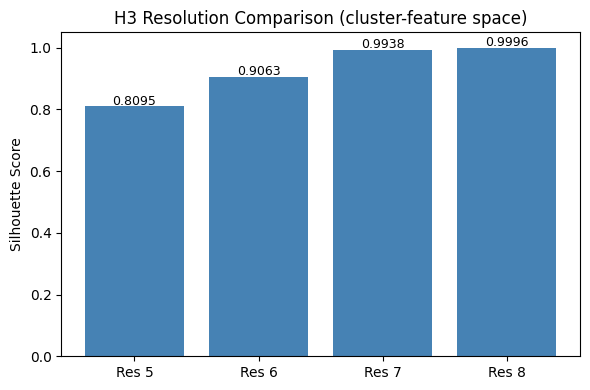

Best H3 resolution: 8 (silhouette=0.9996)
config.H3_RESOLUTION is currently set to: 7 (fixed, matches original report)


In [5]:
from preprocessing.pipeline import evaluate_h3_resolutions

print("Evaluating H3 resolutions 5-8 on a 10k subsample...")
h3_scores = evaluate_h3_resolutions(df_train, resolutions=[5, 6, 7, 8])

fig, ax = plt.subplots(figsize=(6, 4))
resolutions = list(h3_scores.keys())
scores      = list(h3_scores.values())
ax.bar([f"Res {r}" for r in resolutions], scores, color="steelblue")
ax.set_ylabel("Silhouette Score")
ax.set_title("H3 Resolution Comparison (cluster-feature space)")
for i, s in enumerate(scores):
    ax.text(i, s + 0.005, f"{s:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.PLOTS_DIR, "h3_resolution_comparison.png"), dpi=120)
plt.show()

best_res = max(h3_scores, key=h3_scores.get)
print(f"Best H3 resolution: {best_res} (silhouette={h3_scores[best_res]:.4f})")
print(f"config.H3_RESOLUTION is currently set to: 7 (fixed, matches original report)")


## 5 Weather Group Distribution

Top 15 Weather_Condition values (raw):
Weather_Condition
Fair                1792886
Mostly Cloudy        710906
Cloudy               571972
Clear                566671
Partly Cloudy        489500
Overcast             267516
Light Rain           247021
Scattered Clouds     143078
Light Snow            90215
Fog                   69504
Rain                  58947
Haze                  53355
Fair / Windy          25025
Heavy Rain            22640
Light Drizzle         15964
Name: count, dtype: int64


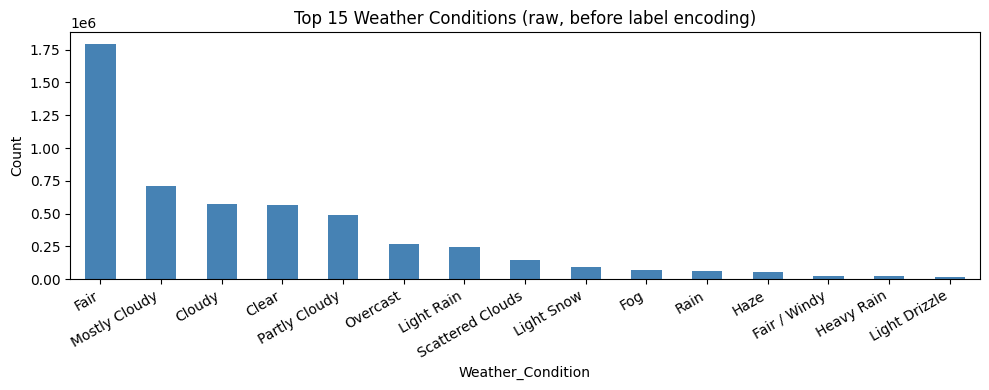

In [ ]:
# Distribution of raw Weather_Condition top values:
wc_counts = df_train["Weather_Condition"].value_counts().head(15)
print("Top 15 Weather_Condition values (raw):")
print(wc_counts)

fig, ax = plt.subplots(figsize=(10, 4))
wc_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 15 Weather Conditions (raw, before label encoding)")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(config.PLOTS_DIR, "weather_condition_distribution.png"), dpi=120)
plt.show()


## 6 Run Full Preprocessing Pipeline

In [7]:
import time
t0 = time.time()

pipeline = PreprocessingPipeline()
X_train, y_train = pipeline.fit_transform(df_train)

elapsed = time.time() - t0
print(f'\nfit_transform completed in {elapsed:.1f}s')
print(f'X_train shape: {X_train.shape}')
print(f'Feature count: {len(pipeline.feature_cols)}')
print(f'Features: {pipeline.feature_cols}')

=== PreprocessingPipeline.fit_transform ===
[1/8] Parsing timestamps -> Duration_Seconds...
[2/8] Cleaning Wind_Direction...
[3/8] H3 resolution 7 + KMeans(10000 clusters)...
      KMeans: 10000 clusters on 163485 unique H3 cells
[4/8] Dropping columns...
[5/8] Mean-imputing numerical features...
[6/8] Dropping NaN rows + duplicates...
      Dropped 250237 rows
[7/8] Encoding features...
[8/8] StandardScaler...
fit_transform complete. Features: 20

fit_transform completed in 1502.6s
X_train shape: (5159638, 20)
Feature count: 20
Features: ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Weather_Condition', 'Amenity', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Civil_Twilight', 'Duration_Seconds', 'Cluster']


In [8]:
X_val,  y_val  = pipeline.transform(df_val)
X_test, y_test = pipeline.transform(df_test)
print(f'Val shape:  {X_val.shape},  Test shape: {X_test.shape}')

Val shape:  (1119891, 20),  Test shape: (1120369, 20)


## 7 Mutual Information Scores

Computing mutual information (may take ~1min on 350k rows)...


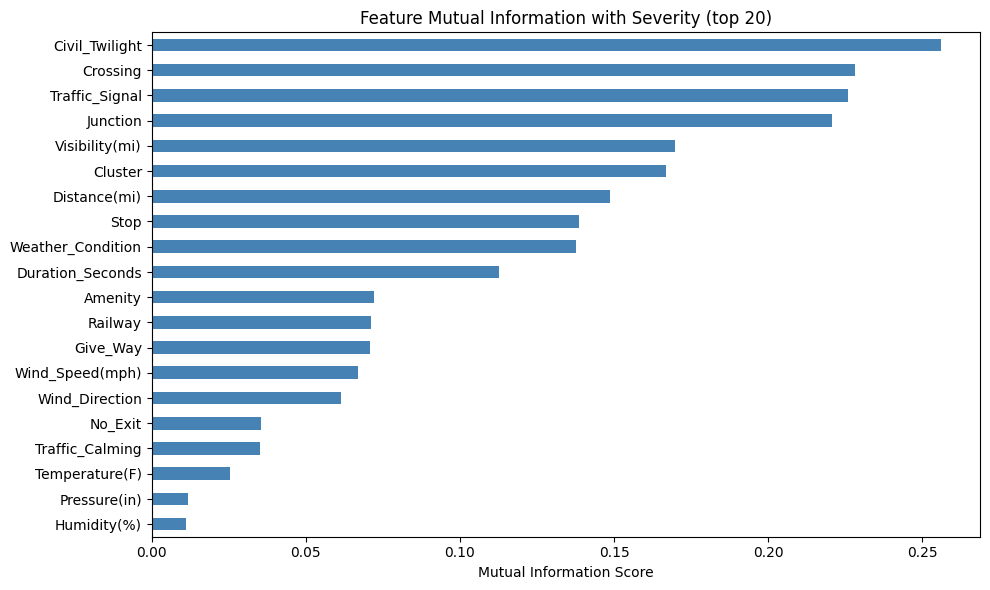

Top 10 features by MI:
Civil_Twilight       0.2560
Crossing             0.2283
Traffic_Signal       0.2259
Junction             0.2209
Visibility(mi)       0.1697
Cluster              0.1670
Distance(mi)         0.1486
Stop                 0.1387
Weather_Condition    0.1378
Duration_Seconds     0.1128
Gate check PASSED: top 5 features all have MI > 0.03


In [9]:
print("Computing mutual information (may take several minutes on full dataset)...")
mi_scores = pipeline.compute_mutual_information(X_train, y_train)

top20 = mi_scores.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Feature Mutual Information with Severity (top 20)")
plt.tight_layout()
plt.savefig(os.path.join(config.PLOTS_DIR, "mutual_information.png"), dpi=120)
plt.show()

print("Top 10 features by MI:")
print(mi_scores.head(10).round(4).to_string())

top5_min = mi_scores.head(5).min()
if top5_min > 0.03:
    print(f"Gate check PASSED: top 5 features all have MI > 0.03")
else:
    print(f"Gate check WARNING: top 5 MI min = {top5_min:.4f}")


## 8 Correlation Heatmap of Final Features

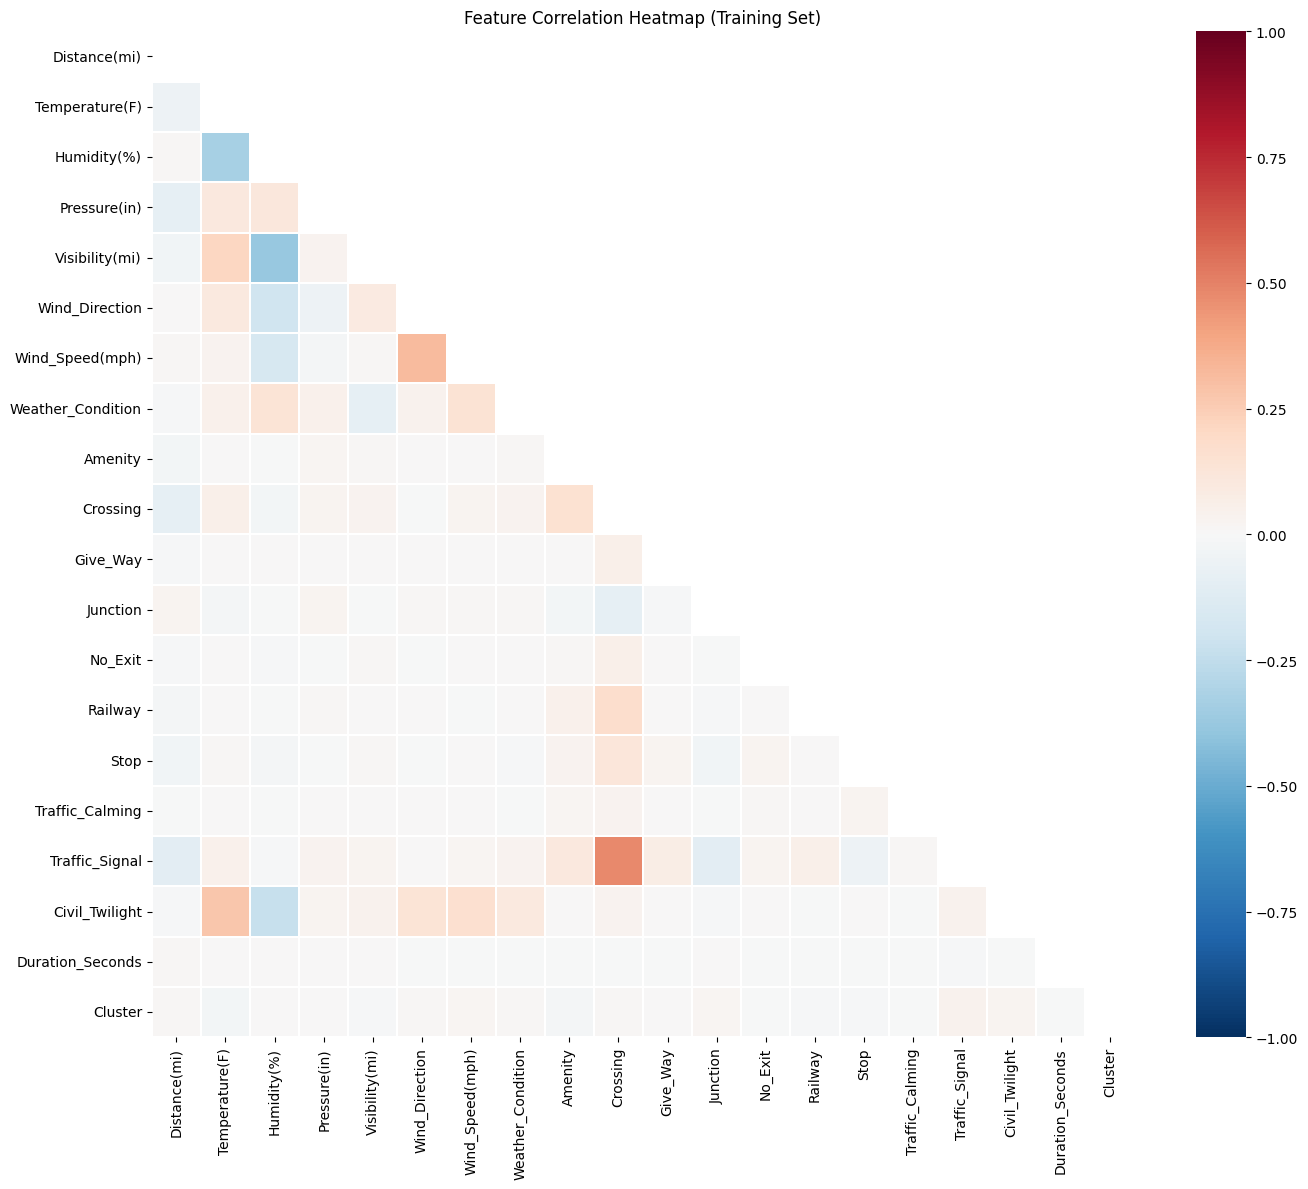

In [10]:
X_train_df = pd.DataFrame(X_train, columns=pipeline.feature_cols)
corr = X_train_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.savefig(os.path.join(config.PLOTS_DIR, 'correlation_heatmap.png'), dpi=120)
plt.show()

## 9 Feature Count Summary

In [11]:
print(f'Raw columns in dataset:         {df_raw.shape[1]}')
print(f'Final features after pipeline:  {len(pipeline.feature_cols)}')
print(f'\nFinal feature list:')
for i, f in enumerate(pipeline.feature_cols, 1):
    print(f'  {i:2d}. {f}')

Raw columns in dataset:         46
Final features after pipeline:  20

Final feature list:
   1. Distance(mi)
   2. Temperature(F)
   3. Humidity(%)
   4. Pressure(in)
   5. Visibility(mi)
   6. Wind_Direction
   7. Wind_Speed(mph)
   8. Weather_Condition
   9. Amenity
  10. Crossing
  11. Give_Way
  12. Junction
  13. No_Exit
  14. Railway
  15. Stop
  16. Traffic_Calming
  17. Traffic_Signal
  18. Civil_Twilight
  19. Duration_Seconds
  20. Cluster


## 10 Sample Rows of Preprocessed Data

In [12]:
sample_df = pd.DataFrame(X_train[:5], columns=pipeline.feature_cols)
sample_df['Severity'] = y_train[:5]
sample_df

,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Weather_Condition,Amenity,Crossing,...,Junction,No_Exit,Railway,Stop,Traffic_Calming,Traffic_Signal,Civil_Twilight,Duration_Seconds,Cluster,Severity
0,1.897023,-0.882728,0.402253,-0.708258,0.337761,0.041347,1.565521,1.144407,-0.112539,-0.359276,...,-0.282283,-0.05057,-0.09318,-0.16889,-0.0316,-0.418938,-1.697408,0.002413,0.290318,2
1,-0.311118,1.069587,-1.136542,0.185485,0.337761,-0.662731,1.000341,-0.730971,-0.112539,2.783373,...,-0.282283,-0.05057,-0.09318,-0.16889,-0.0316,-0.418938,0.589134,-0.025324,-0.857886,2
2,1.595657,0.647465,-0.433093,-0.798637,0.337761,-0.134672,1.188734,1.282303,-0.112539,-0.359276,...,-0.282283,-0.05057,-0.09318,-0.16889,-0.0316,-0.418938,0.589134,-0.015968,0.637242,2
3,-0.138748,-0.249545,-1.092577,-3.931758,0.337761,-0.662731,-0.318414,1.282303,-0.112539,-0.359276,...,-0.282283,-0.05057,-0.09318,-0.16889,-0.0316,-0.418938,0.589134,-0.029071,-0.106900,4
4,-0.311118,1.280649,-0.081368,-0.698216,0.337761,0.217367,2.507489,-0.703392,-0.112539,-0.359276,...,-0.282283,-0.05057,-0.09318,-0.16889,-0.0316,2.386987,0.589134,-0.025330,-0.130508,2


## 11 Save Pipeline

In [13]:
pipeline.save()
print('Pipeline saved.')

# Also save processed arrays for Phase 2
import numpy as np
np.save(os.path.join(config.OUTPUTS_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(config.OUTPUTS_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(config.OUTPUTS_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(config.OUTPUTS_DIR, 'y_val.npy'),   y_val)
np.save(os.path.join(config.OUTPUTS_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(config.OUTPUTS_DIR, 'y_test.npy'),  y_test)
print('Arrays saved to outputs/')

Pipeline saved to e:\Projects\Accident Severity Prediction\outputs\models\preprocessing_pipeline.pkl
Pipeline saved.
Arrays saved to outputs/
